In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/SmartChef/Fruit_Images_Dataset.zip', 'r') as z:
    z.extractall('/content/Fruit_Images_Dataset')

with zipfile.ZipFile('/content/drive/MyDrive/SmartChef/freiburg_groceries_dataset.zip', 'r') as z:
    z.extractall('/content/freiburg_groceries_dataset')

In [ ]:
import os                    # for working with folders and file paths
import shutil                # for copying files (used when merging the datasets)
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf          # the main deep learning library
from tensorflow import keras     # high level tool inside tensorflow, easier to use
from tensorflow.keras import layers  # the building blocks of our CNN model


print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


In [ ]:
DATASET_1_PATH = '/content/Fruit_Images_Dataset/Fruit_Images_Dataset/Images'
DATASET_2_PATH = '/content/freiburg_groceries_dataset/freiburg_groceries_dataset/images'

#the merged folder will be created automatically in the next step
MERGED_PATH = '/content/merged_dataset'

IMG_SIZE   = (128, 128)  #all images will be resized to this size
BATCH_SIZE = 32          #how many images the model sees at once during training
EPOCHS     = 10          #how many times the model goes through the full training data
RANDOM_SEED = 42         #keeps the data split the same every time we run the code

In [ ]:
#this function copies all category folders from both datasets into one combined folder
def merge_datasets(source_paths, destination):

    os.makedirs(destination, exist_ok=True)  #create the merged folder if it doesn't exist

    for source in source_paths:
        for category in os.listdir(source):
            src_category_path = os.path.join(source, category)

            #skip anything that is not a folder (like readme files etc.)
            if not os.path.isdir(src_category_path):
                continue

            dst_category_path = os.path.join(destination, category)
            os.makedirs(dst_category_path, exist_ok=True)

            #copy each image into the matching category folder
            for image_file in os.listdir(src_category_path):
                src_file = os.path.join(src_category_path, image_file)
                dst_file = os.path.join(dst_category_path, image_file)

                #if a file with the same name already exists, add a small prefix to avoid overwriting
                if os.path.exists(dst_file):
                    base, ext = os.path.splitext(image_file)
                    dst_file = os.path.join(dst_category_path, f"ds2_{base}{ext}")

                shutil.copy2(src_file, dst_file)

        print(f'Done copying: {source}')

    categories = sorted(os.listdir(destination))
    print(f'\nTotal categories: {len(categories)}')
    print('Categories:', categories)


#run the merge
merge_datasets([DATASET_1_PATH, DATASET_2_PATH], MERGED_PATH)

Done copying: /content/Fruit_Images_Dataset/Fruit_Images_Dataset/Images
Done copying: /content/freiburg_groceries_dataset/freiburg_groceries_dataset/images

Total categories: 62
Categories: ['Apple', 'Avocado', 'BEANS', 'Banana', 'Beetroot', 'CAKE', 'CANDY', 'CEREAL', 'CHIPS', 'CHOCOLATE', 'COFFEE', 'CORN', 'Cauliflower', 'Cherry', 'Chestnut', 'Clementine', 'Corn', 'Dates', 'Eggplant', 'FISH', 'FLOUR', 'Ginger Root', 'Grape', 'Grapefruit', 'HONEY', 'Hazelnut', 'JAM', 'JUICE', 'Kohlrabi', 'Lemon', 'Limes', 'MILK', 'Mandarine', 'Mango', 'NUTS', 'Nectarine', 'Nut Pecan', 'OIL', 'Onion', 'Orange', 'PASTA', 'Peach', 'Pear', 'Pepper', 'Pineapple', 'Plum', 'Pomegranate', 'Potato', 'RICE', 'SODA', 'SPICES', 'SUGAR', 'Strawberry', 'Sweet Potato', 'TEA', 'TOMATO_SAUCE', 'Tomato', 'Tomato Cherry Red', 'VINEGAR', 'WATER', 'Walnut', 'Watermelon']


In [ ]:
#load all images from the merged folder
#keras automatically reads the subfolders and uses their names as category labels
full_dataset = keras.utils.image_dataset_from_directory(
    MERGED_PATH,
    image_size=IMG_SIZE,
    batch_size=None,       #load one by one so we can split manually later
    shuffle=True,          #mix the images so the model doesn't see them in order
    seed=RANDOM_SEED,
    label_mode='int'       #each category gets a number: 0, 1, 2 ... 62
)

CLASS_NAMES = full_dataset.class_names  #list of all 63 category names
NUM_CLASSES = len(CLASS_NAMES)          #63

print('Total categories loaded:', NUM_CLASSES)
print('Categories:', CLASS_NAMES)

Found 26789 files belonging to 62 classes.
Total categories loaded: 62
Categories: ['Apple', 'Avocado', 'BEANS', 'Banana', 'Beetroot', 'CAKE', 'CANDY', 'CEREAL', 'CHIPS', 'CHOCOLATE', 'COFFEE', 'CORN', 'Cauliflower', 'Cherry', 'Chestnut', 'Clementine', 'Corn', 'Dates', 'Eggplant', 'FISH', 'FLOUR', 'Ginger Root', 'Grape', 'Grapefruit', 'HONEY', 'Hazelnut', 'JAM', 'JUICE', 'Kohlrabi', 'Lemon', 'Limes', 'MILK', 'Mandarine', 'Mango', 'NUTS', 'Nectarine', 'Nut Pecan', 'OIL', 'Onion', 'Orange', 'PASTA', 'Peach', 'Pear', 'Pepper', 'Pineapple', 'Plum', 'Pomegranate', 'Potato', 'RICE', 'SODA', 'SPICES', 'SUGAR', 'Strawberry', 'Sweet Potato', 'TEA', 'TOMATO_SAUCE', 'Tomato', 'Tomato Cherry Red', 'VINEGAR', 'WATER', 'Walnut', 'Watermelon']


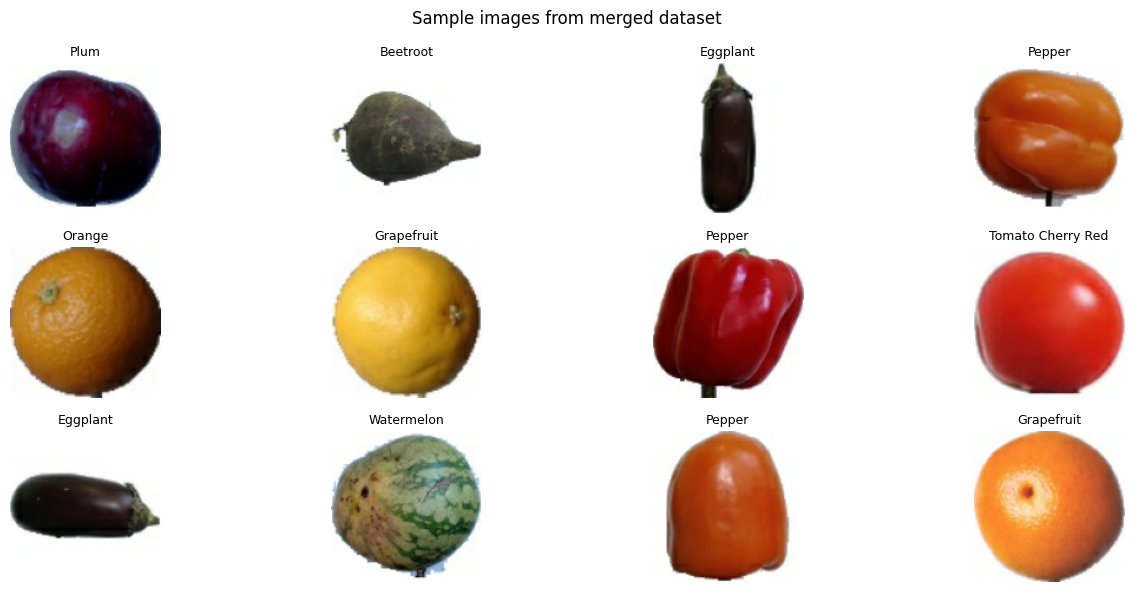

In [ ]:
#show 12 random images from the dataset so we can visually confirm everything looks correct
plt.figure(figsize=(14, 6))

for i, (image, label) in enumerate(full_dataset.take(12)):
    plt.subplot(3, 4, i + 1)
    plt.imshow(image.numpy().astype('uint8'))
    plt.title(CLASS_NAMES[label.numpy()], fontsize=9)
    plt.axis('off')

plt.suptitle('Sample images from merged dataset')
plt.tight_layout()
plt.show()

In [ ]:
#count how many images we have in total
total_images = len(full_dataset)
print('Total images:', total_images)

#calculate how many go into each set
train_size = int(total_images * 0.70)  # 70% for training
val_size   = int(total_images * 0.15)  # 15% for validation
test_size  = total_images - train_size - val_size  # 15% for testing

print(f'Train: {train_size} | Validation: {val_size} | Test: {test_size}')

#split the dataset
train_ds = full_dataset.take(train_size)
val_ds   = full_dataset.skip(train_size).take(val_size)
test_ds  = full_dataset.skip(train_size + val_size)

#batch and prefetch makes training faster
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print('Split done!')

Total images: 26789
Train: 18752 | Validation: 4018 | Test: 4019
Split done!


In [ ]:
#build the CNN model
model = keras.Sequential([

    #normalize pixel values from 0-255 to 0-1, makes training more stable
    layers.Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    #convolutional block 1
    #32 filters, each one learns to detect a different simple feature (edges, colors)
    layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling2D(),  # reduces image size by half, keeps the important features

    #convolutional block 2
    #64 filters, learns more complex features by building on block 1
    layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    #convolutional block 3
    # 128 filters, learns even more complex features like shapes and textures
    layers.Conv2D(128, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    #flatten converts the 2D feature maps into a 1D list of numbers
    layers.Flatten(),

    #dense layer learns which combination of features belongs to which category
    layers.Dense(256, activation='relu'),

    #dropout randomly turns off 30% of neurons during training to avoid overfitting
    layers.Dropout(0.3),

    #output layer - one node per category, gives the probability for each one
    layers.Dense(NUM_CLASSES, activation='softmax')
])

#print a summary of the model structure
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │        15,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,498,046 (32.42 MB)

 Trainable params: 8,498,046 (32.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model = keras.models.load_model('/content/drive/MyDrive/SmartChef/food_classifier_model.keras')

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Model loaded!')

Model loaded!


In [ ]:
#compile the model - tell it how to learn
model.compile(
    optimizer='adam',              #adam is the most common optimizer, works well in most cases
    loss='sparse_categorical_crossentropy',  #standard loss function for multi-class classification
    metrics=['accuracy']           #we want to see accuracy after each epoch
)

#start training!
history = model.fit(
    train_ds,                      #the training data
    epochs=EPOCHS,                 #how many times to go through all the training images
    validation_data=val_ds         #check performance on validation set after each epoch
)

Epoch 1/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 999s 2s/step - accuracy: 0.7086 - loss: 1.1170 - val_accuracy: 0.8547 - val_loss: 0.5191
Epoch 2/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 1015s 2s/step - accuracy: 0.8496 - loss: 0.5206 - val_accuracy: 0.8664 - val_loss: 0.4637
Epoch 3/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 1004s 2s/step - accuracy: 0.8749 - loss: 0.4156 - val_accuracy: 0.8716 - val_loss: 0.4648
Epoch 4/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 981s 2s/step - accuracy: 0.9014 - loss: 0.3252 - val_accuracy: 0.8925 - val_loss: 0.4016
Epoch 5/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 959s 2s/step - accuracy: 0.9167 - loss: 0.2735 - val_accuracy: 0.8838 - val_loss: 0.4277
Epoch 6/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 1005s 2s/step - accuracy: 0.9393 - loss: 0.1965 - val_accuracy: 0.8947 - val_loss: 0.4142
Epoch 7/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 981s 2s/step - accuracy: 0.9540 - loss: 0.1459 - val_accuracy: 0.8952 - val_loss: 0.4669
Epoch 8/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 980s 2s/step - accuracy: 0.9614 - loss: 0.1286 - val_a

In [ ]:
import json
with open('/content/drive/MyDrive/SmartChef/class_names.json', 'r') as f:
    CLASS_NAMES = json.load(f)

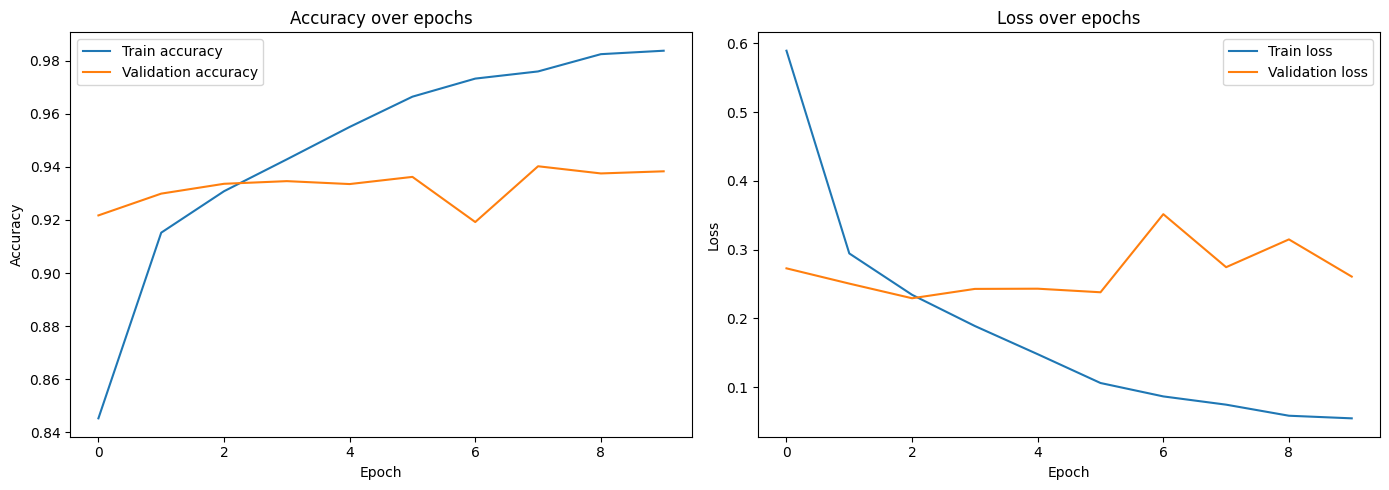

In [ ]:
accuracy     = [0.8453, 0.9152, 0.9308, 0.9428, 0.9550, 0.9664, 0.9732, 0.9759, 0.9824, 0.9837]
val_accuracy = [0.9217, 0.9299, 0.9336, 0.9346, 0.9335, 0.9362, 0.9192, 0.9402, 0.9375, 0.9383]
loss         = [0.5895, 0.2946, 0.2344, 0.1890, 0.1480, 0.1061, 0.0866, 0.0746, 0.0585, 0.0547]
val_loss     = [0.2729, 0.2507, 0.2294, 0.2430, 0.2433, 0.2381, 0.3517, 0.2746, 0.3150, 0.2609]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(accuracy,     label='Train accuracy')
ax1.plot(val_accuracy, label='Validation accuracy')
ax1.set_title('Accuracy over epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(loss,     label='Train loss')
ax2.plot(val_loss, label='Validation loss')
ax2.set_title('Loss over epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_ds)

print(f'Test Loss: {round(test_loss, 4)}')
print(f'Test Accuracy: {round(test_accuracy * 100, 2)}%')

126/126 ━━━━━━━━━━━━━━━━━━━━ 72s 411ms/step - accuracy: 0.8766 - loss: 0.6276
Test Loss: 0.6276
Test Accuracy: 87.66%


In [ ]:
# save to Drive
model.save('/content/drive/MyDrive/SmartChef/food_classifier_model.keras')

# also save the class names so we don't need to reload the dataset next time
import json
with open('/content/drive/MyDrive/SmartChef/class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f)

print('Model and class names saved!')

Model and class names saved!


In [ ]:
#Accuracy
from sklearn.metrics import accuracy_score

# get predictions on the test set
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

accuracy = accuracy_score(y_true, y_pred)
print(f'Accuracy: {round(accuracy * 100, 2)}%')

Accuracy: 88.01%


In [ ]:
#Precision, Recall, F1 Score
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
print(report)

                   precision    recall  f1-score   support

            Apple       0.99      1.00      1.00       138
          Avocado       1.00      1.00      1.00        66
            BEANS       0.08      0.08      0.08        13
           Banana       1.00      1.00      1.00        88
         Beetroot       1.00      1.00      1.00        67
             CAKE       0.50      0.05      0.09        21
            CANDY       0.31      0.36      0.33        44
           CEREAL       0.29      0.32      0.30        38
            CHIPS       0.17      0.17      0.17        30
        CHOCOLATE       0.22      0.33      0.27        45
           COFFEE       0.26      0.31      0.28        36
             CORN       0.12      0.08      0.10        12
      Cauliflower       1.00      1.00      1.00       111
           Cherry       1.00      1.00      1.00        75
         Chestnut       1.00      1.00      1.00        71
       Clementine       1.00      1.00      1.00       

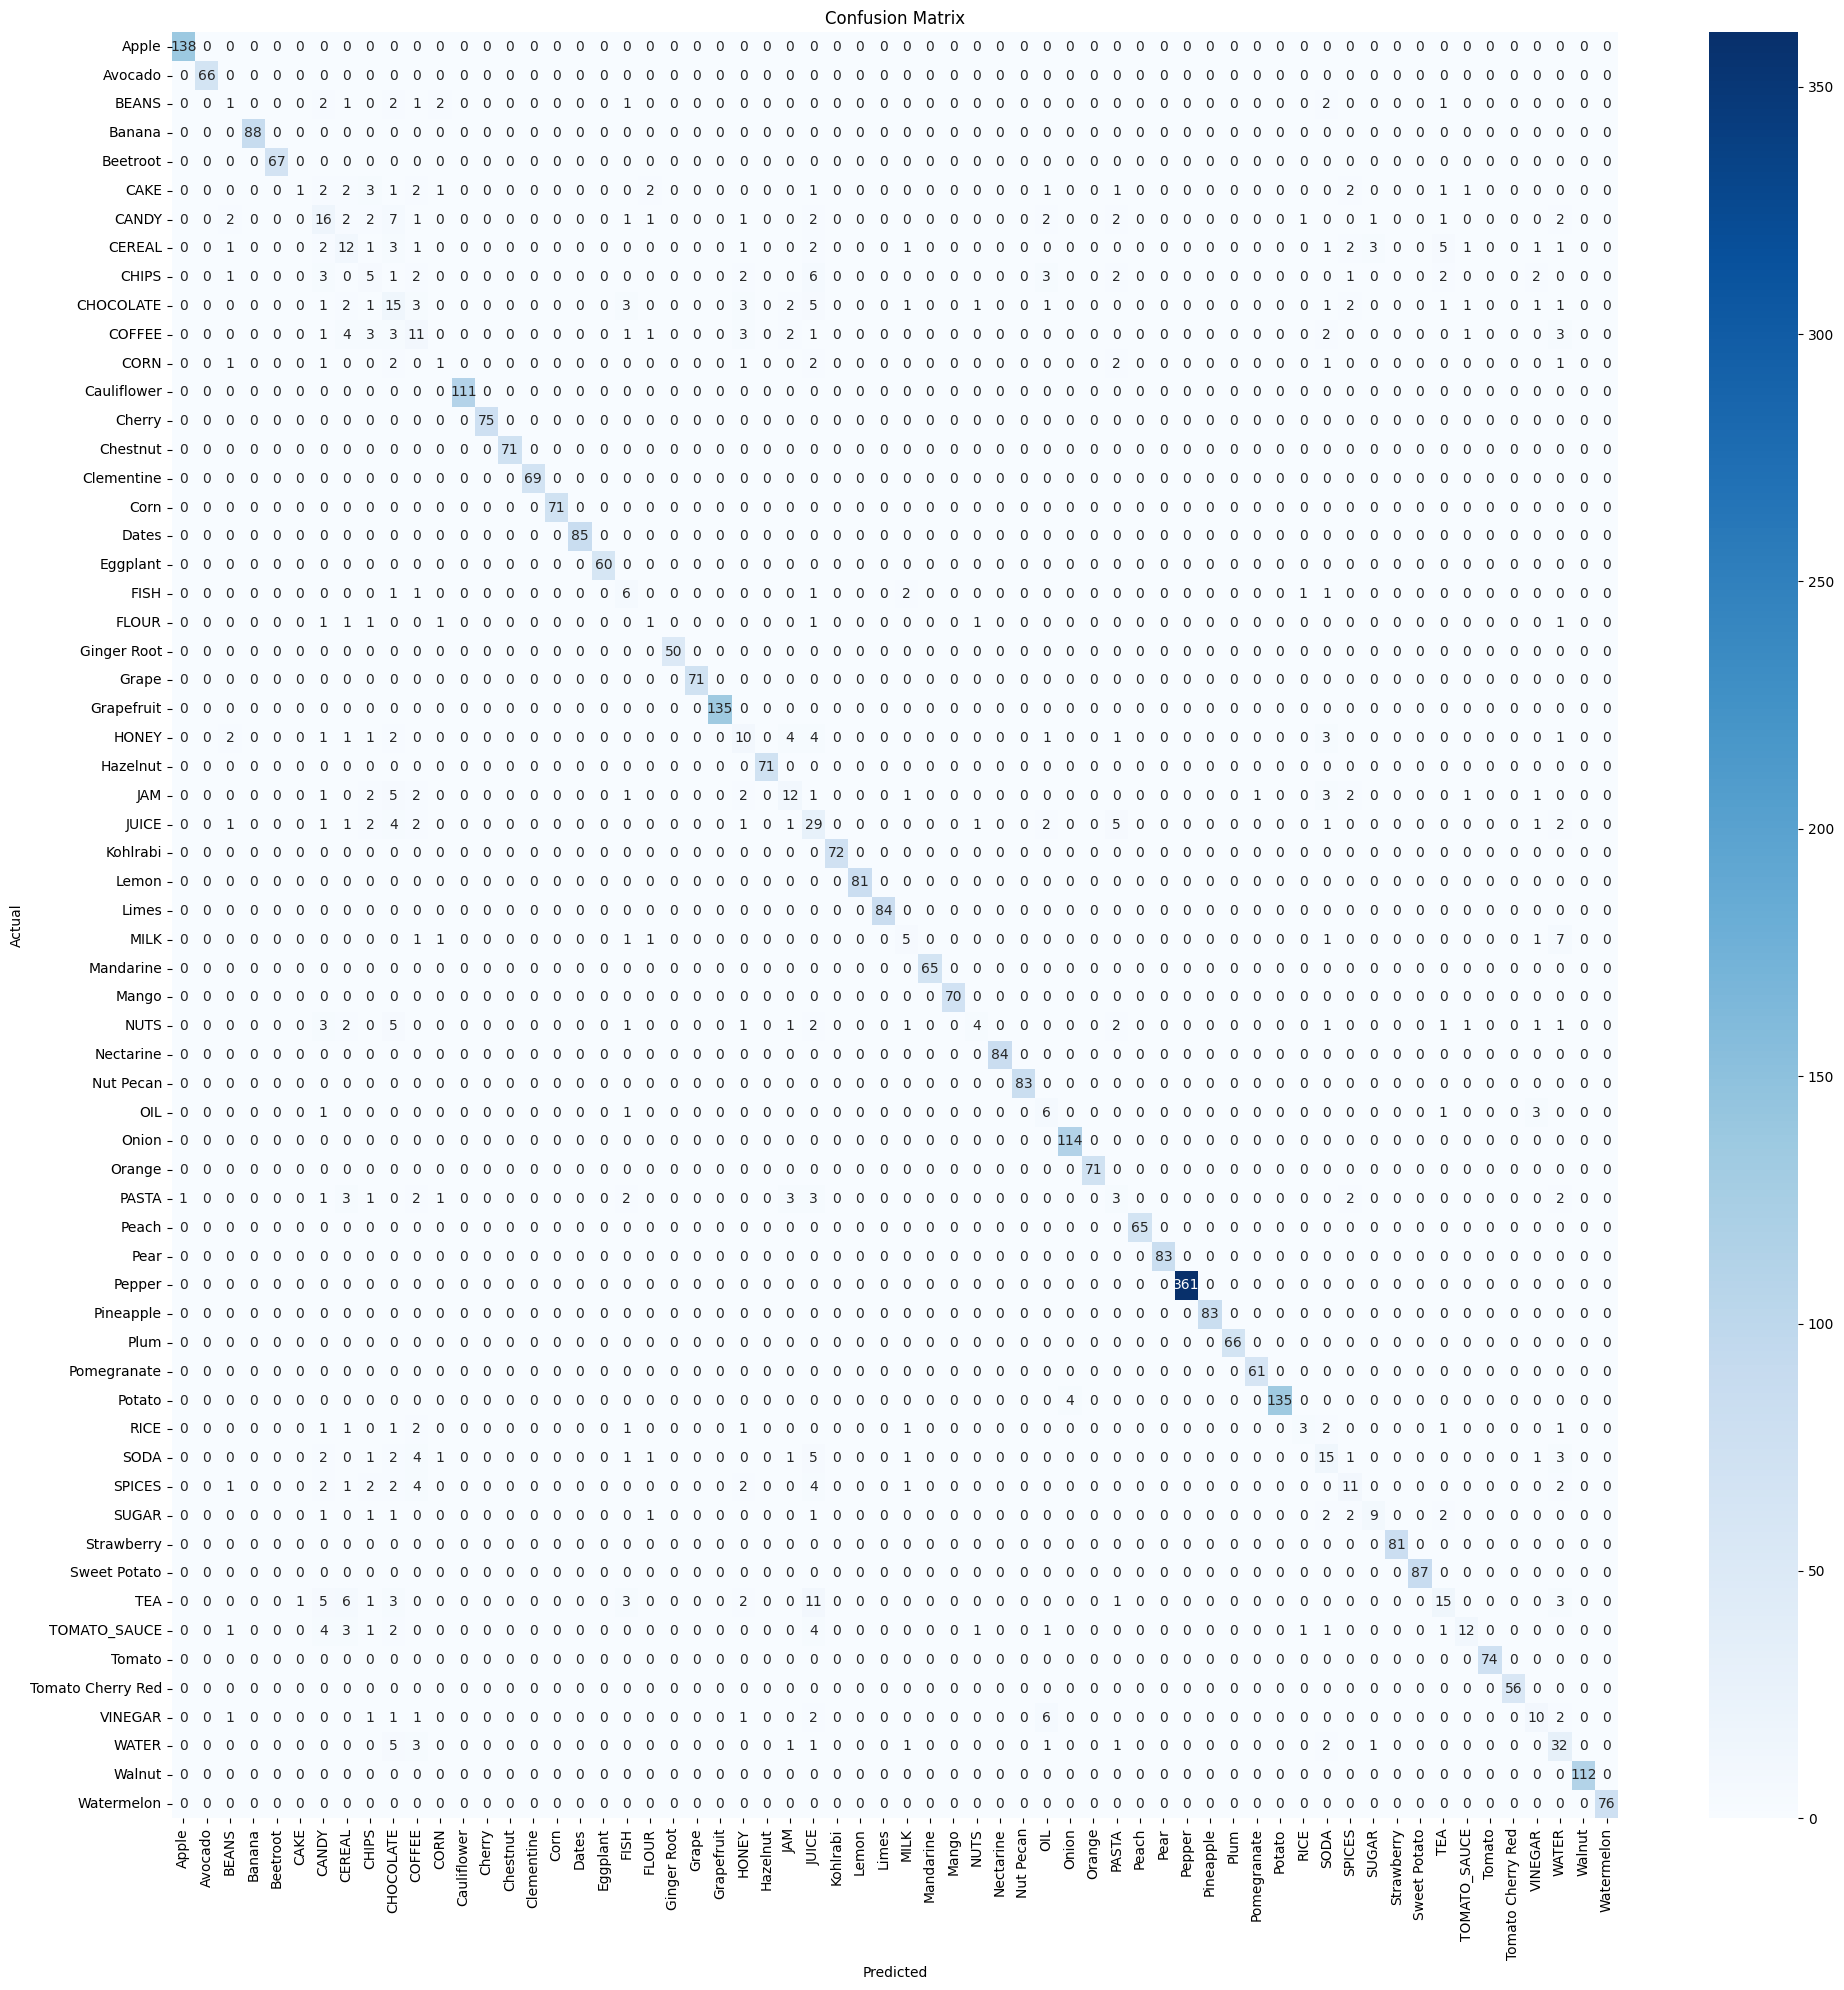

In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()